# core

> Fill in a module description here

In [ ]:
#| default_exp core

In [ ]:
#| export
import numpy as np

import torch
import torch.nn.functional as F # F.mse_loss
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch import nn

import torch_sparse 


import re # name_cleanup

from graphviz import Digraph

import lightning as pl

import plotly.express as px

In [ ]:
#| hide
from nbdev.showdoc import *

## Visualizing graphs 

In [ ]:
#| export
def name_cleanup(input = '7_1_2_1P-TypeH+-ExportingTransporter', newline_char_threshold = 10):
    inp = input
    # remove "7_1_2_1" type from front of name
    rm_front = re.match(r'^[\d|_]+', inp)
    if rm_front:
        inp = inp[rm_front.span()[1]:]

    word_splits = [e.span()[0] for e in re.finditer('[a-z][A-Z]', inp)]

    word_list = []
    i = 0
    for jth in range(len(word_splits)):
        j = word_splits[jth]
        j += 1
        word_list += [inp[i:j]]
        i = j

        if jth+1 == len(word_splits):
            word_list += [inp[i:len(inp)]]

    x = []
    n = 0
    for e in word_list:
        n += len(e)
        if n >= newline_char_threshold:
            x += ['\n'+e]
            n = len(e)
        else:
            x += [' '+e]
    x = ''.join(x).strip('^ ')

    # if the name was only numerics keep the name as is
    if x != '':
        pass
    elif inp != '':
        x = inp
    elif inp == '':
        x = input

    return(x)

In [ ]:
name_cleanup(input = '987987897', newline_char_threshold = 10)

'987987897'

In [ ]:
#| export

def dict_to_digraph(edge_dict):
    dot = Digraph()
    for key in edge_dict.keys():
        key_label = name_cleanup(input = key, newline_char_threshold = 20)+'\n '
        dot.node(key, key_label)
        for value in edge_dict[key]:
            # edge takes a head/tail whereas edges takes name pairs concatednated (A, B -> AB)in a list
            dot.edge(value, key)    
    return dot

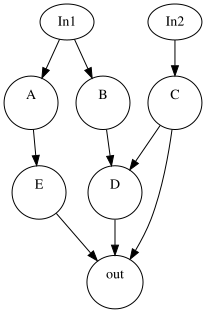

In [ ]:
dict_to_digraph(edge_dict = {'A': ['In1'],
 'B': ['In1'],
 'C': ['In2'],
 'D': ['B', 'C'],
 'E': ['A'],
 'out': ['C', 'D', 'E']}
 )

## Translate between different graph representations (dict <--> matrix)

In [ ]:
#| export

def rand_connection_matrix(num_nodes:int = 10 # number of nodes in graph
                           )-> torch.tensor: # Tensor with 1's representing connections
    "Returns a nxn matrix with zeros on the diagonal and lower half. A 1 indicates the column depends on that row."  
    out = torch.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        # require at least one connection for all but the last i
        while out[i, ].sum() == 0:
            num_vals = (num_nodes-1-i)
            out[i, (i+1):num_nodes] = torch.bernoulli(torch.rand((1, num_vals)))
            if i == num_nodes-1:
                break
    return out

In [ ]:
#| export

def connection_matrix_to_dict(
    connections:torch.tensor , # Tensor with 1's representing connections between nodes. A random one can be generated with `rand_connection_matrix` 
    node_names = None # Optional list of names for the nodes. If none is provided nodes will be named "0" to "n".
    )-> dict:
    "Convert a matrix represenation of a graph to a dictionary of the edges structured as `{<parent>:[<children>], ... }`"
    print('This function is deprecated. Please see `sparsevnn.util.convert_connections`')
    connections = connections.to(int)
    if node_names == None:
        node_names = [str(i) for i in range(connections.shape[0])]
    # in connections 0 is no connection. But since we are getting indices and a connection _could_ be at index 0 if these are shuffled we mask the empty connections before multiplying
    mask_0 = (connections == 0)
    idxs = torch.linspace(0, connections.shape[0]-1, connections.shape[0]).to(int)
    idxs = connections * idxs # now we have a matrix of indices. 

    edge_dict = {}

    for i in range(connections.shape[0]):
        i_idxs = idxs[i, (~mask_0[i, ])].tolist() 

        if i_idxs == []:
            pass
        else:
            edge_dict = edge_dict | {node_names[i]: [node_names[j] for j in i_idxs]}
    # add any nodes that have no children as {a:[]} to be compliant with original version
    edge_dict = edge_dict | {
        e:[] for e in 
        list(set(sum([edge_dict[k] for k in edge_dict.keys()], [])))
        if e not in edge_dict.keys()}

    return edge_dict

In [ ]:
#| export

def connection_dict_to_matrix(edge_dict:dict # Dictionary representation of of a graph's edges structured as `{<parent>:[<children>], ... }`
                              )->torch.tensor:
    "Convert a dictionary of a graph's edges into a tensor with 1's representing connections between nodes."
    print('This function is deprecated. Please see `sparsevnn.util.convert_connections`')
    keys = edge_dict.keys()
    key2num = dict(zip(keys, [i for i in range(len(keys))]))

    out = torch.zeros((len(keys), len(keys)))

    for key in keys:
        for depend in edge_dict[key]:
            out[key2num[depend], key2num[key]] = 1
    return out

In [ ]:
connections = rand_connection_matrix(num_nodes = 6)
px.imshow(connections)

This function is deprecated. Please see `sparsevnn.util.convert_connections`
{'0': ['4'], '1': ['3'], '2': ['3', '4'], '3': ['4'], '4': ['5'], '5': []}


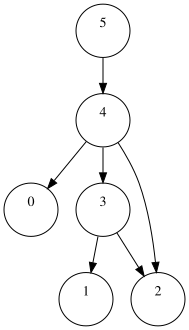

In [ ]:
connection_dict = connection_matrix_to_dict(
    connections = connections,
    node_names = None)
print(connection_dict)
dict_to_digraph(edge_dict = connection_dict)

In [ ]:
# These are not guaranteed to be identical because the col/rows might be shuffled. 
# confirm the representations are equivalent
# (connection_dict_to_matrix(edge_dict = connection_dict) - connections).min() == 0

## SparseLinearCustom
This class is extends Daniel Hyeonwoo Yoo's [`SparseLinear`](https://github.com/hyeon95y/SparseLinear), which itself builds on Matthias Fey's [`pytorch_sparse`](https://github.com/rusty1s/pytorch_sparse). I'm deeply grateful for these projects being open sourced -- It saved me a ton of time. Daniel and Matthias, if you're out there -- thank you. 

In [ ]:
#| export

class SparseLinearCustom(nn.Module):
    """Applies a linear transformation to the incoming data: :math:`y = xA^T + b`
    
    Args:
        in_features: size of each input sample
        out_features: size of each output sample
        bias: If set to ``False``, the layer will not learn an additive bias.
            Default: ``True``
        sparsity: sparsity of weight matrix
            Default: 0.9
        connectivity: user defined sparsity matrix
            Default: None
        small_world: boolean flag to generate small world sparsity
            Default: ``False``
        dynamic: boolean flag to dynamically change the network structure
            Default: ``False``
        deltaT (int): frequency for growing and pruning update step
            Default: 6000
        Tend (int): stopping time for growing and pruning algorithm update step
            Default: 150000
        alpha (float): f-decay parameter for cosine updates
            Default: 0.1
        max_size (int): maximum number of entries allowed before chunking occurrs
            Default: 1e8
    
    Shape:
        - Input: :math:`(N, *, H_{in})` where :math:`*` means any number of
          additional dimensions and :math:`H_{in} = \text{in\_features}`
        - Output: :math:`(N, *, H_{out})` where all but the last dimension
          are the same shape as the input and :math:`H_{out} = \text{out\_features}`.
    
    Attributes:
        weight: the learnable weights of the module of shape
            :math:`(\text{out\_features}, \text{in\_features})`. The values are
            initialized from :math:`\mathcal{U}(-\sqrt{k}, \sqrt{k})`, where
            :math:`k = \frac{1}{\text{in\_features}}`
        bias:   the learnable bias of the module of shape :math:`(\text{out\_features})`.
                If :attr:`bias` is ``True``, the values are initialized from
                :math:`\mathcal{U}(-\sqrt{k}, \sqrt{k})` where
                :math:`k = \frac{1}{\text{in\_features}}`
    
    Examples::
        
        >>> m = nn.SparseLinear(20, 30)
        >>> input = torch.randn(128, 20)
        >>> output = m(input)
        >>> print(output.size())
        torch.Size([128, 30])
    """

    def __init__(self, in_features, out_features, bias=True, sparsity=0.9, connectivity=None, small_world=False, dynamic=False, deltaT=6000, Tend=150000, alpha=0.1, max_size=1e8,
                 custom_weights=None, custom_bias=None, 
                 weight_grad_bool=None, bias_grad_bool=None, # indices in sparse format for those entries that should have their gradients NOT zeroed (non identity cells)
                 dropout_p=0.0, # apply dropout  
                 # dropout should either be applied at a consistent rate with dropout_p (which will ignore identity cells unless bias_grad_bool is none) 
                 # OR should be provided as a vector of dropout probabilities which will can be used to provide a specific dropout to a specific node.
                 nonlinear_transform=None # What is the non-linear transformation that should be applied to the non-identity units?
                 ):
        assert in_features < 2**31 and out_features < 2**31 and sparsity < 1.0
        assert connectivity is None or not small_world, "Cannot specify connectivity along with small world sparsity"
        if connectivity is not None:
            assert isinstance(connectivity, torch.LongTensor) or isinstance(connectivity, torch.cuda.LongTensor), "Connectivity must be a Long Tensor"
            assert connectivity.shape[0]==2 and connectivity.shape[1]>0, "Input shape for connectivity should be (2,nnz)"
            assert connectivity.shape[1] <= in_features*out_features, "Nnz can't be bigger than the weight matrix"
        super(SparseLinearCustom, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.connectivity = connectivity
        self.small_world = small_world
        self.dynamic = dynamic
        self.max_size = max_size


        self.weight_grad_bool = None
        self.bias_grad_bool   = None
        if weight_grad_bool != None:
            self.weight_grad_bool = nn.Parameter(weight_grad_bool).requires_grad_(False)

        if bias_grad_bool != None:
            self.bias_grad_bool    = nn.Parameter(bias_grad_bool).requires_grad_(False)
        

        # dropout should be None, a float, or a tensor.
        if dropout_p == None:
            self.dropout_p = dropout_p  
        else:
            if isinstance(dropout_p, float):
                assert 0.0 <= dropout_p and dropout_p <= 1.0
                self.dropout_p = dropout_p
            elif isinstance(dropout_p, torch.Tensor):
                assert dropout_p.shape[0] == out_features
                # if dropout isn't None then it should be a parameter so it ends up on the right device.
                self.dropout_p = nn.Parameter(dropout_p).requires_grad_(False)

        self.nonlinear_transform = nonlinear_transform

        # Generate and coalesce indices
        coalesce_device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu') # Faster to coalesce on GPU
        if not small_world:
            if connectivity is None:
                self.sparsity = sparsity
                nnz = round((1.0-sparsity) * in_features * out_features)
                if in_features * out_features <= 10**8:
                    indices = np.random.choice(in_features * out_features, nnz, replace=False)
                    indices = torch.as_tensor(indices, device=coalesce_device)
                    row_ind = indices.floor_divide(in_features)
                    col_ind = indices.fmod(in_features)
                else:
                    warnings.warn("Matrix too large to sample non-zero indices without replacement, sparsity will be approximate", RuntimeWarning)
                    row_ind = torch.randint(0, out_features, (nnz,), device=coalesce_device)
                    col_ind = torch.randint(0, in_features, (nnz,), device=coalesce_device)
                indices = torch.stack((row_ind, col_ind))
            else:
                # User defined sparsity
                nnz = connectivity.shape[1]
                self.sparsity = nnz/(out_features*in_features)
                connectivity = connectivity.to(device=coalesce_device)
                indices = connectivity
                
        else:
            #Generate small world sparsity
            self.sparsity = sparsity
            nnz = round((1.0-sparsity) * in_features * out_features)
            assert nnz > min(in_features, out_features), 'The matrix is too sparse for small-world algorithm; please decrease sparsity'
            offset = abs(out_features - in_features) / 2.

            # Node labels
            inputs = torch.arange(1 + offset * (out_features > in_features), in_features + 1 + offset * (out_features > in_features), device=coalesce_device)
            outputs = torch.arange(1 + offset * (out_features < in_features), out_features + 1 + offset * (out_features < in_features), device=coalesce_device)

            total_data = in_features * out_features                 # Total params
            chunks = math.ceil(total_data / self.max_size)
            split_div = max(in_features, out_features) // chunks    # Full chunks
            split_mod = max(in_features, out_features) % chunks     # Remaining chunk
            idx = torch.repeat_interleave(torch.Tensor([split_div]), chunks).int().to(device=coalesce_device)
            idx[:split_mod] += 1
            idx = torch.cumsum(idx, dim=0)
            idx = torch.cat([torch.LongTensor([0]).to(device=coalesce_device), idx])

            count = 0

            rows = torch.empty(0).long().to(device=coalesce_device)
            cols = torch.empty(0).long().to(device=coalesce_device)

            def small_world_chunker(inputs, outputs, nnz):
                pair_distance = inputs.view(-1, 1) - outputs
                arg = torch.abs(pair_distance) + 1.
                # lambda search
                error = float('inf')
                L, U = 1e-5, 5.  
                lamb = 1.                   # initial guess
                itr = 1
                error_threshold = 10.
                max_itr = 1000
                P = arg**(-lamb)
                P_sum = P.sum()
                error = abs(P_sum - nnz)

                while error > error_threshold:
                    assert itr <= max_itr, 'No solution found; please try different network sizes and sparsity levels'
                    if P_sum < nnz:
                        U = lamb
                        lamb = (lamb + L) / 2.
                    elif P_sum > nnz:
                        L = lamb
                        lamb = (lamb + U) / 2.
                        
                    P = arg**(-lamb)
                    P_sum = P.sum()
                    error = abs(P_sum - nnz)
                    itr += 1
                return P

            for i in range(chunks):
                inputs_ = inputs[idx[i]:idx[i+1]] if out_features <= in_features else inputs
                outputs_ = outputs[idx[i]:idx[i+1]] if out_features > in_features else outputs

                y = small_world_chunker(inputs_, outputs_, round(nnz / chunks))
                ref = torch.rand_like(y)
                
                mask = torch.empty(y.shape, dtype=bool).to(device=coalesce_device)
                mask[y < ref] = False
                mask[y >= ref] = True

                rows_, cols_ = mask.to_sparse().indices()

                rows = torch.cat([rows, rows_ + idx[i]])
                cols = torch.cat([cols, cols_])

            indices = torch.stack((cols, rows))
            nnz = indices.shape[1]

        # Extending this code to allow for values to be passed in.
        if custom_weights == None:
            values = torch.empty(nnz, device=coalesce_device)
        else:
            # print('ding')
            values = custom_weights.to(coalesce_device)
            # print(values)
        indices, values = torch_sparse.coalesce(indices, values, out_features, in_features)
        # print(values)
        
        self.register_buffer('indices', indices.cpu())
        self.weights = nn.Parameter(values.cpu())
        # print(self.weights)


        if bias:
            # also extending bias to allow for custom bias vector
            if custom_bias == None:
                self.bias = nn.Parameter(torch.Tensor(out_features))
            else:
                self.bias = nn.Parameter(custom_bias)
            
        else:
            self.register_parameter('bias', None)
        
        if self.dynamic:
            self.deltaT = deltaT
            self.Tend = Tend
            self.alpha = alpha
            self.itr_count = 0

        custom_weights_bool = True if custom_weights is not None else False
        custom_bias_bool    = True if custom_bias    is not None else False

        self.reset_parameters(custom_weights_bool=custom_weights_bool, 
                              custom_bias_bool= custom_bias_bool)

    def reset_parameters(self, custom_weights_bool, custom_bias_bool):
        # only do if parameters were not manually set:
        bound = 1 / self.in_features**0.5
        if custom_weights_bool:
            pass
        else:
            nn.init.uniform_(self.weights, -bound, bound)
        if custom_bias_bool:
            pass
        elif self.bias is not None:
            nn.init.uniform_(self.bias, -bound, bound)

    @property
    def weight(self):
        """ returns a torch.sparse.FloatTensor view of the underlying weight matrix 
            This is only for inspection purposes and should not be modified or used in any autograd operations
        """
        weight = torch.sparse.FloatTensor(self.indices, self.weights, (self.out_features, self.in_features))
        return weight.coalesce().detach()

    def forward(self, inputs):
        if self.dynamic:
            self.itr_count+= 1
        output_shape = list(inputs.shape)
        output_shape[-1] = self.out_features

        # Handle dynamic sparsity
        if self.training and self.dynamic and self.itr_count < self.Tend and self.itr_count%self.deltaT==0:
            
            #Drop criterion
            f_decay = self.alpha * (1 + math.cos(self.itr_count * math.pi/self.Tend))/2
            k = int(f_decay *( 1 - self.sparsity ) * self.weights.view(-1,1).shape[0])
            n = self.weights.shape[0]
            
            _, lm_indices = torch.topk(-torch.abs(self.weights),n-k, largest=False, sorted=False)

            self.indices = torch.index_select(self.indices,1, lm_indices)
            self.weights = nn.Parameter(torch.index_select(self.weights, 0, lm_indices))

            device = inputs.device
            #Growth criterion
            self.weights = nn.Parameter(torch.cat((self.weights,((torch.zeros(k))).to(device=device)),dim=0))
            self.indices = torch.cat((self.indices,torch.zeros((2,k), dtype=torch.long).to(device=device)),dim=1)
            output = GrowConnections.apply( inputs, self.weights, k, self.indices, (self.out_features, self.in_features), self.max_size)

        else:

            if len(output_shape) == 1: inputs = inputs.view(1, -1)
            inputs = inputs.flatten(end_dim=-2)

            output = torch_sparse.spmm(self.indices, self.weights, self.out_features, self.in_features, inputs.t()).t()
            if self.bias is not None:
                output += self.bias
                        
        if self.training and self.dropout_p != None:
            # adding in support for dropout on all outputs or on only those that are not identity
            if isinstance(self.dropout_p, float):
                # to match nn.dropout it this must be the prob of a value being zeroed
                probs = torch.tensor(1-self.dropout_p).repeat(output.shape)
                
            elif isinstance(self.dropout_p, torch.Tensor):
                probs =              1-self.dropout_p.repeat(output.shape[0], 1)

            # if passing in a tensor of probabilities to be used then this SHOULD not be needed. 
            if self.bias_grad_bool != None: # assume weight == 2, identity == 1
                weight_outputs   =    (-1+self.bias_grad_bool)
                identity_outputs = -1*(-2+self.bias_grad_bool)

                # move tensors to gpu if needed.
                probs     = probs.to(output.device)
                temp_ones = torch.ones(output.shape).to(output.device)
                
                # zero out pr for the identity cells then elementwise add with a matrix of 1s with the weight cells zeroed.
                probs = probs*weight_outputs+(temp_ones*identity_outputs)
                # probs = probs*weight_outputs+(torch.ones(output.shape)*identity_outputs)
            output = output*torch.bernoulli(probs)

        # apply nonlinear tranform (e.g. relu) to the non-identity outputs
        if self.nonlinear_transform is not None:
            # apply transform to all?
            if self.bias_grad_bool == None: 
                output = self.nonlinear_transform(output)

            elif self.bias_grad_bool != None: # assume weight == 2, identity == 1
                weight_outputs   =    (-1+self.bias_grad_bool)
                identity_outputs = -1*(-2+self.bias_grad_bool)

                output_transformed = self.nonlinear_transform(output)
                # keep transformed values only on non-identity outputs
                output = (output_transformed*weight_outputs)+(output*identity_outputs)

        return output.view(output_shape)

    def extra_repr(self):
        return 'in_features={}, out_features={}, bias={}, sparsity={}, connectivity={}, small_world={}'.format(
            self.in_features, self.out_features, self.bias is not None, self.sparsity, self.connectivity, self.small_world
        )

## Visible Neural Networks

In [ ]:
#| export
class VNNHelper():
    def __init__(self, edge_dict, all_values_are_nodes = True) -> None:
        self.edge_dict = edge_dict.copy()
        # handles updating all the lists of node groups (imp, out, edge)
        self._setup_wrapper(all_values_are_nodes)

        self.node_props = {}
        for e in self.node_keys_vals['all_keys']:
            self.node_props[e] = {}

    def _setup_wrapper(self, all_values_are_nodes):
        if all_values_are_nodes:
            self._init_missing_nodes_as_input()
        self.node_keys_vals = self._find_uniq_keys_values(input_dict = self.edge_dict)
        self.nodes_inp = self._find_nodes_inp(all_key_value_dict = self.node_keys_vals)
        self.nodes_out = self._find_top_nodes(all_key_value_dict = self.node_keys_vals)
        self.nodes_edge= self._find_nodes_edge(all_key_value_dict= self.node_keys_vals, nodes_inp= self.nodes_inp, nodes_out = self.nodes_out)
        # sets self.dependancy_order
        self._get_run_order()

    # CRUD operations on node proprty dictionary
    def node_prop_create(self, name):
        self.node_props[name] = {}
        
    def node_prop_read_keys(self, name):
        return self.node_props[name].keys()

    def node_prop_read_values(self, name, key):
        return self.node_props[name][key]

    def node_prop_update(self, name, key, value):
        self.node_props[name][key] = value

    def node_prop_delete(self, name, key=None):
        if key == None:
            del self.node_props[name]
        else:
            del self.node_props[name][key]


    def _find_uniq_keys_values(self, input_dict):
        """
        Building a Neural Net from an arbitrary graph
        start by finding the top level -- all those keys which are theselves not values
        helper function to get all keys and all value from a dict. Useful for when keys don't have unique values.
        """
        all_keys = list(input_dict.keys())
        all_values = []
        for e in all_keys:
            all_values.extend(input_dict[e])
        all_values = list(set(all_values))

        return({'all_keys': all_keys, 'all_values': all_values})

    def _find_top_nodes(self, all_key_value_dict):
        """
        Find order that nodes in the graph should be called to have all dependencies run when they are called.
        find the dependancies for run order from many dependancies to none
        wrapper function to find the nodes that aren't any other nodes dependancies.
        """
        return([e for e in all_key_value_dict['all_keys'] if e not in all_key_value_dict['all_values']])
    
    def _init_missing_nodes_as_input(self):
        node_keys_vals = self._find_uniq_keys_values(input_dict = self.edge_dict)
        add_these_nodes = [e for e in node_keys_vals['all_values'] if e not in node_keys_vals['all_keys']]
        for e in add_these_nodes:
            self.edge_dict[e] = []

    def _find_nodes_inp(self, all_key_value_dict):
        # """
        # wrapper function to find the input nodes. They don't occur in the keys and thus won't be added to the list otherwise.
        # another way to do this would have been to 
        # """
        # return([e for e in all_key_value_dict['all_values'] if e not in all_key_value_dict['all_keys']])
        return [e for e in all_key_value_dict['all_keys'] if self.edge_dict[e] == []]

    def _find_nodes_edge(self, all_key_value_dict, nodes_inp, nodes_out):
        return [e for e in all_key_value_dict['all_keys'] if e not in nodes_inp+nodes_out]

    def append_output_node(self, node_name):
        if node_name in self.edge_dict.keys():
            pass
        else:
            self.edge_dict[node_name] = self.nodes_out
            self._setup_wrapper()
            self.node_prop_create(name = node_name)

    def _get_run_order(self, max_iter = 1000):
        temp = self.edge_dict.copy()
        dependancy_order = []
        # Then iterate
        for _ in range(max_iter): 
            top_nodes = self._find_top_nodes(all_key_value_dict = self._find_uniq_keys_values(input_dict = temp))
            if top_nodes == []:
                break
            else:
                dependancy_order += top_nodes    
                # remove nodes from the graph that are at the 'top' level and haven't already been removed
                for key in [e for e in dependancy_order if e in temp.keys()]:
                    temp.pop(key)

        # reverse to get the order that the nodes should be called
        dependancy_order.reverse()                
        self.dependancy_order = dependancy_order


    def set_node_props(self, key, node_val_zip):
        for name, val in node_val_zip:
            self.node_prop_update(name = name, key=key, value=val)
    
    def calc_edge_inp(self):
        for name in self.nodes_edge + self.nodes_out: 
            inp_size = sum([self.node_prop_read_values(name = e, key= 'out') for e in self.edge_dict[name]])
            self.node_prop_update(name = name, key='inp', value=inp_size)     

    def mk_digraph(self, include = ['node_name', 'inp_size', 'out_size']):
        dot = ''
        dot = Digraph()
        for key in self.node_props.keys():
            key_label = []

            if 'node_name' in include: key_label += [key]
            if 'inp_size' in include: key_label += ['In  '+str(self.node_props[key]['inp'])]
            if 'out_size' in include: key_label += ['Out '+str(self.node_props[key]['out'])]
            
            if len(key_label) == 0:
                key_label = ''
            else:
                key_label = '\n'.join(key_label)

            dot.node(key, key_label)
            for value in self.edge_dict[key]:
                # edge takes a head/tail whereas edges takes name pairs concatednated (A, B -> AB)in a list
                dot.edge(value, key)    
        return dot

In [ ]:
#| export

# wrapper to make description dictionary
def mk_NodeGroups(edge_dict, dependancy_order):    # for using sparse matrix implementation
        # Take a pass through the dependency order and check that each node comes after all of its dependanies.
        # check dep order
        tally = []
        for d in dependancy_order:
            if edge_dict[d] == []:
                tally.append(d)
            elif False not in [True if e in tally else False for e in edge_dict[d]]:
                tally.append(d)
            else:
                print('error!')
                break

        # Now go through each of the nodes and create chunks containing all the nodes that _do not depend_ on any other nodes in the current chunk. 

        #            - A -------
        #           /           \
        # 100278565 -- B -- D -- y_hat
        #                  /    /
        # 100383860 -> C -------

        #     ['100278565', '100383860',      'C', 'B', 'D', 'A', 'y_hat'] # Example: `dependancy_order` 
        # {0: ['100278565', '100383860'], 1: ['C', 'B', 'A'], 2: ['D'], 3: ['y_hat']} # Example: `d_out`

        # build output nodes 
        d_out = {0:[]}
        for d in dependancy_order:
            if edge_dict[d] == []:
                d_out[min(d_out.keys())].append(d)
            else:
                # print((d, edge_dict[d]))

                d_out_i = 1+max(sum([[key for key in d_out.keys() if e in d_out[key]]
                        for e in edge_dict[d]], []))
                
                if d_out_i not in d_out.keys():
                    d_out[d_out_i] = []
                d_out[d_out_i].append(d)

        # {3: ['C', 'A'], 2: [], 1: []}

        # build index of dependencies that are not calculated in the previous set
        d_eye = {}
        tally = []
        for i in range(max(d_out.keys()), min(d_out.keys()), -1):
            # print(i)
            nodes_needed = sum([edge_dict[e] for e in d_out[i]], [])+tally
            # check against what is there and then dedupe
            nodes_needed = [e for e in nodes_needed if e not in d_out[i-1]]
            nodes_needed = list(set(nodes_needed))
            tally = nodes_needed
            d_eye[i] = nodes_needed
        
        # build an index of the set of nodes and which values are in the inputs, outputs, or outputs that are not calcuated in this set. 

        # {3: {'out': ['y_hat'],                  'inp': ['D'],                      'eye': ['C', 'A']},
        #  2: {'out': ['D'],                      'inp': ['C', 'B', 'A'],            'eye': []},
        #  1: {'out': ['C', 'B', 'A'],            'inp': ['100278565', '100383860'], 'eye': []},
        #  0: {'out': ['100278565', '100383860'], 'inp': ['100278565', '100383860'], 'eye': []}}

        dd = {}
        for i in d_eye.keys():
            dd[i] = {'out': d_out[i],
                    'inp': d_out[i-1],
                    'eye': d_eye[i]}
            
        # plus special 0 layer that handles the snps
        dd[0] = {'out': d_out[0],
                'inp': d_out[0],
                'eye': []}

        # check that the output nodes' inputs are satisfied by the same layer's inputs (inp and eye)

        for i in dd.keys():
            # out node in each
            for e in dd[i]['out']:
                # node depends in inp/eye
                node_pass_list = [True if ee in dd[i]['inp']+dd[i]['eye'] else False 
                                for ee in edge_dict[e]]
                if False not in node_pass_list:
                    pass
                else:
                    print('exit') 
        return dd

In [ ]:
#| export

class structured_layer_info:
    def __init__(self, i, 
                 node_groups,  
                 # {1: {'out': ['OtherTubulinModificationProteins',
                      #      'inp': [
                      #      'eye': [
                 node_props, # {'KeggOrthology(Ko)[Br-Zma00001]': {'out': 1, 'reps': 1, 'drop': 0.0, 'inp': 7},
                 edge_dict,
                 inp_tensor_nucleotides= 4, # What's the length of the nucleotide dimension? Used to calculate the start/stop positions of the input idx in the 0th layer.
                 inp_tensor_lookup = None, # Optional to lookup node idx for the input tensor. This is important if two genes might share snps (e.g. two genes fall in between markers)
                 as_sparse = False
                 ):
        dd = node_groups # used to be called description dictionary. TODO replace in below.
        self.row_inp = dd[i]['inp']
        self.row_eye = dd[i]['eye']

        self.col_out = dd[i]['out']
        self.col_eye = []
        if i+1 in dd.keys():
            self.col_eye = dd[i+1]['eye'] 

        # build lookup dicts of the information on each side
        row_nodes = [e for e in self.row_inp+self.row_eye]
        col_nodes = [e for e in self.col_out+self.col_eye]

        if i == min(dd.keys()):
            row_sizes = [node_props[e]['inp'] for e in row_nodes]
            # print(row_sizes)
        else:
            row_sizes = [node_props[e]['out'] for e in row_nodes]
        col_sizes = [node_props[e]['out'] for e in col_nodes]

        row_sizes = torch.Tensor(row_sizes).to(torch.int)
        row_stop  = torch.cumsum(row_sizes, 0)
        row_start = torch.concat([torch.Tensor([0]).to(torch.int), row_stop[0:-1]])
        # print(row_start)
        # print(row_stop)

        col_sizes = torch.Tensor(col_sizes).to(torch.int)
        col_stop  = torch.cumsum(col_sizes, 0)
        col_start = torch.concat([torch.Tensor([0]).to(torch.int), col_stop[0:-1]])

        self.row_info = {}
        for j in range(len(row_sizes)):
            self.row_info[row_nodes[j]]= {
                'size': row_sizes[j],
                'stop':  row_stop[j],
                'start': row_start[j],
            }

        self.col_info = {}
        for j in range(len(col_sizes)):
            self.col_info[col_nodes[j]]= {
                'size': col_sizes[j],
                'stop':  col_stop[j],
                'start': col_start[j],
            }

        if inp_tensor_lookup != None:
            for key in self.row_info.keys():
                idxs = inp_tensor_lookup[key]

                overwrite_row_start = torch.tensor(
                    min(idxs)*inp_tensor_nucleotides).to(torch.int)
                # offset by number of nucleotides because this will be flattened.
                overwrite_row_stop  = torch.tensor(
                    max(idxs)*inp_tensor_nucleotides).to(torch.int) + inp_tensor_nucleotides

                self.row_info[key]['start'] = overwrite_row_start
                self.row_info[key]['stop']  = overwrite_row_stop

                assert (overwrite_row_stop - overwrite_row_start) == self.row_info[key]['size'] 
            
            # Overwrite the row_stop list with a entry list. We only need the last value of the list to init the weight matix
            # if not as_sparse
            max_idx = max(sum([inp_tensor_lookup[k] for k in inp_tensor_lookup], []))
            max_idx = (max_idx*inp_tensor_nucleotides)+inp_tensor_nucleotides
            row_stop = [max_idx]

        
    
        # bias shape does not change based on sparse/none
        self.bias            = torch.zeros([              col_stop[-1]])
        self.bias_eye_bool   = torch.zeros([              col_stop[-1]]) # 1 if is eye

        if not as_sparse:
            ## Init weight & bias matrix ====
            self.weight          = torch.zeros([row_stop[-1], col_stop[-1]])
            self.weight_bool     = torch.zeros([row_stop[-1], col_stop[-1]]) # 1 if is weight
            self.weight_eye_bool = torch.zeros([row_stop[-1], col_stop[-1]]) # 1 if is eye

            for e in self.col_out:
                c_size = self.col_info[e]['size']
                # print(f'i {i} key min {min(dd.keys())}')
                if i == min(dd.keys()):
                    inps = [e]
                else:
                    inps = edge_dict[e]
                # print(f'inps: {inps}')
                # r_size_total = sum([self.row_info[ee]['size'] for ee in inps])
                # W = torch.empty(r_size_total, c_size)
                # W = torch.nn.init.kaiming_normal_(W, a=0, mode='fan_in', nonlinearity='relu')
            
                c1 = self.col_info[e]['start']
                c2 = self.col_info[e]['stop']

                # W_start = 0
                # print(W.shape)
                for inp in inps:
                    r1 = self.row_info[inp]['start']
                    r2 = self.row_info[inp]['stop']
                    slice_size = r2-r1
                    # W_end = W_start + slice_size
                    # print(W_start, W_end)
                    # self.weight[r1:r2, c1:c2] = W[W_start:W_end]

                    # Use nn.Linear to initialize the matrix instead of doing it manually.
                    xx = nn.Linear(slice_size, c_size)
                    W = xx.weight.clone().detach().requires_grad_(False)
                    # print(f'{W.shape} {self.weight[r1:r2, c1:c2].shape}')
                    B = xx.bias.clone().detach().requires_grad_(False)
                    self.weight[r1:r2, c1:c2] = W#.swapaxes(0,1)                                                          # <- transposed to match nn.Linear
                    self.weight_bool[r1:r2, c1:c2] = torch.ones(W.shape)#.swapaxes(0,1) # Fill in gradient bool matrix    # <- transposed to match nn.Linear
                    self.bias[c1:c2] = B
                    # W_start = W_end        
                    
            for e in self.col_eye:
                c_size = self.col_info[e]['size']
                c1 = self.col_info[e]['start']
                c2 = self.col_info[e]['stop']
                r1 = self.row_info[e]['start']
                r2 = self.row_info[e]['stop']

                W = torch.eye(c_size)
                self.weight[r1:r2, c1:c2] = W
                # FIXME testing if not allowing gradients on unity entries is causing the problem. If it is then either 
                # 1. pass through gradients from one layer to the next (and or)
                # 2. re-set these values to unity after each update. 
                self.weight_eye_bool[r1:r2, c1:c2] = torch.eye(c_size)#.swapaxes(0,1)                                     # <- transposed to match nn.Linear

            # if as_sparse:
            #     self.weight      = self.weight.to_sparse()
            #     self.weight_bool = self.weight_bool.to_sparse()
            #     self.weight_eye_bool = self.weight_bool.to_sparse()
            #     # self.bias = self.bias

            ## Init identity components of matrix ====
            # 1.0 if identity otherwise 0
            for e in self.col_eye:
                self.bias_eye_bool[self.col_info[e]['start']:self.col_info[e]['stop']] = 1.0
            if self.col_eye != []:
                self.bias_eye_bool = self.bias_eye_bool 


            # Transpose to match as_sparse output (and desired input for custom sparse linear layer)
            self.weight          = self.weight.swapaxes(0,1)
            self.weight_bool     = self.weight_bool.swapaxes(0,1)
            self.weight_eye_bool = self.weight_eye_bool.swapaxes(0,1)

        elif as_sparse:
            ## Init weight & bias matrix ====
            # self.weight          = torch.zeros([row_stop[-1], col_stop[-1]])
            # self.weight_bool     = torch.zeros([row_stop[-1], col_stop[-1]]) # 1 if is weight
            # self.weight_eye_bool = torch.zeros([row_stop[-1], col_stop[-1]]) # 1 if is eye

            # accumulators
            self.w_acc_indices = None
            self.w_acc_values = None
            
            for e in self.col_out:
                c_size = self.col_info[e]['size']
                # print(f'i {i} key min {min(dd.keys())}')
                if i == min(dd.keys()):
                    inps = [e]
                else:
                    inps = edge_dict[e]
            
                c1 = self.col_info[e]['start']
                c2 = self.col_info[e]['stop']

                for inp in inps:
                    r1 = self.row_info[inp]['start']
                    r2 = self.row_info[inp]['stop']
                    slice_size = r2-r1

                    # Use nn.Linear to initialize the matrix instead of doing it manually.
                    xx = nn.Linear(slice_size, c_size)
                    W = xx.weight.clone().detach().requires_grad_(False)
                    B = xx.bias.clone().detach().requires_grad_(False)

                    W = W.to_sparse()

                    sparse_indices = W.indices()+torch.tensor([[c1],
                                                               [r1]])
                    sparse_values  = W.values()

                    # W = torch.sparse_coo_tensor(sparse_indices, sparse_values) # optional list of shape

                    # if self.weight == None:
                    #     self.weight = W
                    # else: 
                    #     self.weight = torch.concat([self.weight, W], axis = 1)

                    # sparse_indices = torch.concat([
                    #     torch.tensor(sum([[ii for i in range(r1, r2)] for ii in range(c1, c2)], []))[None, :],
                    #     torch.tensor(sum([[i for i in range(r1, r2)] for ii in range(c1, c2)], []))[None, :]
                    #     ], axis = 0)
                    # # [0, 0, 0, 1, 1, 1, 2, 2, 2]
                    # # [3, 4, 5, 3, 4, 5, 3, 4, 5]
                    # # print(sparse_indices)

                    # sparse_values = W.reshape(-1)

                    if self.w_acc_indices == None:
                        self.w_acc_indices = sparse_indices
                    else:
                        self.w_acc_indices = torch.concat([self.w_acc_indices, sparse_indices], axis = 1 )

                    if self.w_acc_values == None:
                        self.w_acc_values = sparse_values
                    else:
                        self.w_acc_values = torch.concat([self.w_acc_values, sparse_values],    axis = 0 )

                    # self.weight_bool[r1:r2, c1:c2] = torch.ones(W.shape).swapaxes(0,1) # Fill in gradient bool matrix    # <- transposed to match nn.Linear
                    self.bias[c1:c2] = B


            bias_grad_bool = torch.zeros(self.bias.shape)
            bias_grad_bool[self.bias != 0] = 1
            self.bias_grad_bool = 1+bias_grad_bool # Encode a weight as 2, eye as 1. This is more work here but allows for use of a sparse matrix below without dropping values that are eye (0) and messing up the length relative to the gradients (because gradients are calculated for the valeues at 1 and then have to be zeroed.)


            self.w_eye_acc_indices = None
            self.w_eye_acc_values  = None
            self.weight_eye_bool   = None

            for e in self.col_eye:
                c_size = self.col_info[e]['size']
                c1 = self.col_info[e]['start']
                c2 = self.col_info[e]['stop']
                r1 = self.row_info[e]['start']
                r2 = self.row_info[e]['stop']

                W = torch.eye(c_size)

                W = W.to_sparse()

                sparse_indices = W.indices()+torch.tensor([[c1],
                                                           [r1]])
                sparse_values = W.values()

                if self.w_eye_acc_indices == None:
                    self.w_eye_acc_indices = sparse_indices
                else:
                    self.w_eye_acc_indices = torch.concat([self.w_eye_acc_indices, sparse_indices], axis = 1 )

                if self.w_eye_acc_values == None:
                    self.w_eye_acc_values = sparse_values
                else:
                    self.w_eye_acc_values = torch.concat([self.w_eye_acc_values, sparse_values],    axis = 0 )


            ## Init identity components of matrix ====
            # 1.0 if identity otherwise 0
            for e in self.col_eye:
                self.bias_eye_bool[self.col_info[e]['start']:self.col_info[e]['stop']] = 1.0
            if self.col_eye != []:
                self.bias_eye_bool = self.bias_eye_bool    


            self.weight = torch.sparse_coo_tensor(
                torch.concat([e for e in [self.w_acc_indices, self.w_eye_acc_indices] if e != None], axis = 1 ), 
                torch.concat([e for e in [self.w_acc_values, self.w_eye_acc_values] if e != None],   axis = 0 )
                )    
            self.weight = self.weight.coalesce()

            # if self.w_eye_acc_indices != None:
            #     self.weight_eye_bool = torch.sparse_coo_tensor(
            #         self.w_eye_acc_indices, 
            #         self.w_eye_acc_values 
            #         )    
            

            self.weight_grad_bool = None
            if self.w_acc_indices != None:
                # self.weight_grad_bool = torch.sparse_coo_tensor(
                #     self.w_acc_indices, 
                #     torch.ones(self.w_acc_values.shape),
                #     self.weight.shape 
                # )
                
                # Encode a weight as 2, eye as 1
                # to get back only weights:  x-1
                # to get back only eyes: -1*(x-2)  
                if ((self.w_acc_values is not None) and 
                    (self.w_eye_acc_values is not None)):
                    self.weight_grad_bool = torch.sparse_coo_tensor(
                        torch.concat([e for e in [self.w_acc_indices, self.w_eye_acc_indices] if e != None], axis = 1 ), 
                        torch.concat([e for e in [1+torch.ones(self.w_acc_values.shape),   # weights are 2
                                                    torch.ones(self.w_eye_acc_values.shape)# eyes are 1
                                                    ] if e != None],   axis = 0 )
                        )
                elif (self.w_acc_values is not None):
                    self.weight_grad_bool = torch.sparse_coo_tensor(
                        self.w_acc_indices,
                        1+torch.ones(self.w_acc_values.shape)
                        )
                elif (self.w_eye_acc_values is not None):
                    self.weight_grad_bool = torch.sparse_coo_tensor(
                        self.w_eye_acc_indices,
                        1+torch.ones(self.w_eye_acc_values.shape)
                        )
                    
                self.weight_grad_bool.coalesce()

            # clean up attributes that aren't needed for downstream functions 
            # weight
            # bias
            # weight_grad_bool
            # bias_grad_bool
        
            # lookup dicts. good to keep
            # del self.row_info   # <- inputs
            # del self.col_info   # <- outputs

            # del self.row_inp
            del self.row_eye
    
            # del self.col_out
            del self.col_eye

            del self.bias_eye_bool

            del self.weight_eye_bool

            del self.w_acc_indices
            del self.w_acc_values
            del self.w_eye_acc_indices
            del self.w_eye_acc_values

        # make dropout for outputs.
        # temp = torch.zeros(self.bias_grad_bool.shape)
        temp = torch.zeros(self.bias.shape)
        # iterate over the non-identiy columns
        for e in self.col_out:
            temp[self.col_info[e]['start']:self.col_info[e]['stop']] = node_props[e]['drop']
        self.dropout_p = temp

# TODO error when as_sparse = False, must need to traspose a matrix:
# Error found in regression test in EnvDL        

# ---------------------------------------------------------------------------
# RuntimeError                              Traceback (most recent call last)
# Cell In[57], line 5
#       1 # old version
#       2 # M_list = [structured_layer_info(i = ii, dd = dd, node_props= node_props, edge_dict = edge_dict) for ii in range(0, max(dd.keys())+1)]
#       3 
#       4 # new version?
# ----> 5 M_list = [structured_layer_info(i = ii, node_groups = dd, node_props= node_props, edge_dict = edge_dict) for ii in range(0, max(dd.keys())+1)]

# Cell In[57], line 5
#       1 # old version
#       2 # M_list = [structured_layer_info(i = ii, dd = dd, node_props= node_props, edge_dict = edge_dict) for ii in range(0, max(dd.keys())+1)]
#       3 
#       4 # new version?
# ----> 5 M_list = [structured_layer_info(i = ii, node_groups = dd, node_props= node_props, edge_dict = edge_dict) for ii in range(0, max(dd.keys())+1)]

# File ~/Documents/sparsevnn/sparsevnn/core.py:727, in structured_layer_info.__init__(self, i, node_groups, node_props, edge_dict, as_sparse)
#     725 # print(f'{W.shape} {self.weight[r1:r2, c1:c2].shape}')
#     726 B = xx.bias.clone().detach().requires_grad_(False)
# --> 727 self.weight[r1:r2, c1:c2] = W#.swapaxes(0,1)                                                          # <- transposed to match nn.Linear
#     728 self.weight_bool[r1:r2, c1:c2] = torch.ones(W.shape)#.swapaxes(0,1) # Fill in gradient bool matrix    # <- transposed to match nn.Linear
#     729 self.bias[c1:c2] = B

# RuntimeError: The expanded size of the tensor (8) must match the existing size (12) at non-singleton dimension 1.  Target sizes: [12, 8].  Tensor sizes: [8, 12]


In [ ]:
#| export

# Expand node replicates (to have multiple layers per node)

def expand_edge_dict(vnn_helper, edge_dict):
    edge_dict_expanded = {} #edge_dict.copy()

    # find the nodes that need to be expanded.
    expand_nodes = [(e, vnn_helper.node_prop_read_values(name=e, key= 'reps'))
                    for e in sum([vnn_helper.nodes_inp, vnn_helper.nodes_edge, vnn_helper.nodes_out], [])
                    if vnn_helper.node_prop_read_values(name=e, key= 'reps') > 1 ]

    # pass through edge dict and add in replicate nodes
    for key in edge_dict.keys():
        expand_node = [e for e in expand_nodes if e[0]==key]
        if expand_node != []:
            expand_node   =  expand_node[0]
            temp_expanded = [expand_node[0]+'_rep_'+str(ii) for ii in range(expand_node[1])]

            # Add the new node with the old node pointing to it. 
            for i in range(0, len(temp_expanded)):
                if i == 0:
                    edge_dict_expanded[temp_expanded[i]] = edge_dict[expand_node[0]]
                else:
                    edge_dict_expanded[temp_expanded[i]] = [temp_expanded[i-1]]
        else:
            edge_dict_expanded[key] = [e for e in edge_dict[key]]
            
    # pass through `edge_dict_expanded` and update all the expanded nodes.
    # if the key is one of the expanded nodes it should be removed (it's already been replicated)
    # if the value is one of the expanded nodes then it should be updated to point to the last replicate.
    for key in edge_dict_expanded.keys():
        values = edge_dict_expanded[key]
        edge_dict_expanded[key] = [
            # This is a mess but what it does is this:
            # for the list of values, if the value isn't in the expanded nodes, return it.
            val if True not in [True if e[0]==val else False for e in expand_nodes] 
            # otherwise return the last node in the sequence of repeats
            else [e[0]+'_rep_'+str(e[1]-1) for e in expand_nodes if e[0]==val][0] 
            for val in values]
    return edge_dict_expanded

In [ ]:
#| export
def _dist_scale_function(out:int, # output size of a node 
                         dist: int, # Distance from the output node 
                         decay_rate: float | int # 0 or positive number. 0 will apply no decay
                         )->int:
    "Scale a value (node output size) as out = (1/(1+decay*dist)) * out, rounding with a minimum of 1."

    scale = 1/(1+decay_rate*dist)
    out = round(scale * out)
    out = max(1, out)
    return out

In [ ]:
import pandas as pd

In [ ]:
_dists  = np.linspace(0, 5, 11)
_decays = np.linspace(0, 1, 5)

res = pd.DataFrame(
    sum(
        [[(d, dc) for d in _dists] for dc in _decays],
        []), 
        columns= ['dist', 'decay']
        )
res['out'] = [_dist_scale_function(out = 100, dist=res.loc[i, 'dist'], decay_rate=res.loc[i, 'decay']) for i in res.index ]

res

import plotly.express as px
px.line(res, x = 'dist', y = 'out', color = 'decay')

In [ ]:
#| export

def info_list_to_layer_list(
        M_list:list, # "Matrix list", a list of `structured_layer_info` objects.
        nonlinearity:F.relu = F.relu # What nonlinear layer should be added between neurons?
        )->list:
    "Convert `structured_layer_info` objects into `SparseLinearCustom` for `sparsevnn`. It used to be called vnn_factory_3"
    layer_list = []
    for i in range(len(M_list)):
        
        apply_nonlinear = None
        if i+1 != len(M_list): # apply relu to all but the last layer
            apply_nonlinear = nonlinearity
        
        l = SparseLinearCustom(
            M_list[i].weight.shape[1], # have to transpose this?
            M_list[i].weight.shape[0],
            connectivity   = torch.LongTensor(M_list[i].weight.coalesce().indices()),
            custom_weights = M_list[i].weight.coalesce().values(), 
            custom_bias    = M_list[i].bias.clone().detach(), 
            weight_grad_bool = M_list[i].weight_grad_bool, 
            bias_grad_bool   = M_list[i].bias_grad_bool, #.to_sparse()#.indices()
            dropout_p        = M_list[i].dropout_p,
            nonlinear_transform= apply_nonlinear
            )

        layer_list += [l]
        
    return layer_list    

In [ ]:
#| export

class SparseVNN(nn.Module):
    def __init__(self, layer_list):
        super(SparseVNN, self).__init__()
        self.layer_list = nn.ModuleList(layer_list)
 
    def forward(self, x):
        for l in self.layer_list:
            x = l(x)
        return x

In [ ]:
#| export

class plDNN_general(pl.LightningModule):
    def __init__(self, mod, log_weight_stats = False):
        super().__init__()
        self.mod = mod
        self.log_weight_stats = log_weight_stats
        
    def training_step(self, batch, batch_idx):
        y_i, x_i = batch
        pred = self.mod(x_i)
        loss = F.mse_loss(pred, y_i)
        self.log("train_loss", loss)
        
        if self.log_weight_stats:
            with torch.no_grad():
                weight_list=[(name, param) for name, param in self.mod.named_parameters() if name.split('.')[-1] == 'weight']
                for l in weight_list:
                    self.log(("train_mean"+l[0]), l[1].mean())
                    self.log(("train_std"+l[0]), l[1].std())        

        return(loss)
        
    def validation_step(self, batch, batch_idx):
        y_i, x_i = batch
        pred = self.mod(x_i)
        loss = F.mse_loss(pred, y_i)
        self.log('val_loss', loss)        
     
    def configure_optimizers(self, **kwargs):
        optimizer = torch.optim.Adam(self.parameters(), **kwargs)
        return optimizer

## Data Setup

In [ ]:
#| export 

class MarkerDataset(Dataset):
    def __init__(
            self,
            lookup_obs, # (n,) idxs containing a subset of idxs in y
            lookup_geno,# (obs, 3) Pheno_Idx, Geno_Idx, Is_Phno (technically only the first two are needed)
            y, # (obs, yvars)
            G  # (genotypes, snps*nucleotides )
    ):
        self.lookup_obs = lookup_obs
        self.lookup_geno = lookup_geno
        self.y = y
        self.G = G
        
    def __len__(self):
        return len(self.lookup_obs)

    # These used to be in __getitem__ but separating them like this allows for them to be overwritten more easily
    def get_y(self, idx):
        y_idx = self.y[idx]
        return(y_idx)
        
    def get_G(self, idx):
        geno_idx = self.lookup_geno[idx, 1]
        G_idx = self.G[geno_idx]
        return(G_idx)
    
    def __getitem__(self, idx):
        out = []
        obs_idx = idx

        return [self.get_y(obs_idx), self.get_G(obs_idx)]

## Network Components

In [ ]:
#| export
def Linear_block(in_size, out_size, drop_pr):
    block = nn.Sequential(
        nn.Linear(in_size, out_size),
        nn.ReLU(),
        nn.Dropout(drop_pr)
    )
    return(block) 

In [ ]:
#| export
def Conv1D_x2_Max_block(in_channels, out_channels, kernel_size, stride, maxpool_size):
    block = nn.Sequential(
        nn.Conv1d(
            in_channels= in_channels, # second channel
            out_channels= out_channels,
            kernel_size= kernel_size,
            stride= stride
        ), 
        nn.Conv1d(
            in_channels= out_channels, 
            out_channels= out_channels,
            kernel_size= kernel_size,
            stride= stride
        ), 
        nn.BatchNorm1d(out_channels),
        nn.MaxPool1d((maxpool_size), stride=stride)
    )
    return(block)

In [ ]:
# Drawing on example version 

n_obs = 100 # 100 obs for each group
y_true = torch.from_numpy(np.concatenate([
        np.zeros((n_obs, )),
        np.ones( (n_obs, ))], 0)) + .1* torch.rand(2*n_obs,)

input_tensor_dict = {
    'in1': torch.from_numpy(np.concatenate([
        np.zeros((n_obs, 4, 3)),
        np.ones( (n_obs, 4, 3))], 0)),
    'in2': torch.from_numpy(np.concatenate([
        np.zeros((n_obs, 4, 2)),  
        np.ones( (n_obs, 4, 2))], 0))}

x_list_temp = [input_tensor_dict[key].to(torch.float) for key in input_tensor_dict.keys()]
[e.shape for e in x_list_temp]


kegg_connections = {
    'y_hat':['d', 'c'],
    'd':['b'],
    'c':['a'],
    'b':['in2', 'a'],
    'a':['in1'],
    'in1': [],
    'in2': []
}

myvnn = VNNHelper(edge_dict = kegg_connections)

myvnn.nodes_inp

['in1', 'in2']

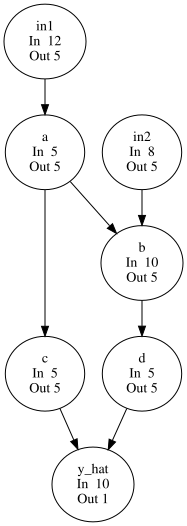

In [ ]:
# init input node sizes
inp_tensor_name_to_size = zip(
    ['in1', 'in2'], 
    [int(torch.prod(torch.tensor(e.shape)[1:])) for e in x_list_temp])

myvnn.set_node_props(key = 'inp', node_val_zip = inp_tensor_name_to_size)

# init node output sizes
myvnn.set_node_props(key = 'out', node_val_zip = zip(myvnn.nodes_inp, [5 for e in myvnn.nodes_inp]))
myvnn.set_node_props(key = 'out', node_val_zip = zip(myvnn.nodes_edge,[5 for e in myvnn.nodes_edge]))
myvnn.set_node_props(key = 'out', node_val_zip = zip(myvnn.nodes_out, [1 for e in myvnn.nodes_out]))


# options should be controlled by node_props
myvnn.set_node_props(key = 'flatten', node_val_zip = zip(
    myvnn.nodes_inp, 
    [True for e in myvnn.nodes_inp]))

myvnn.set_node_props(key = 'reps', node_val_zip = zip(
    myvnn.nodes_out+myvnn.nodes_inp+myvnn.nodes_edge, 
    [1 for e in myvnn.nodes_out+myvnn.nodes_inp+myvnn.nodes_edge]))

# init dropout 
myvnn.set_node_props(key = 'drop', node_val_zip = zip(
    myvnn.nodes_out+myvnn.nodes_inp+myvnn.nodes_edge, 
    [0.0 for e in myvnn.nodes_out+myvnn.nodes_inp+myvnn.nodes_edge]))

# init edge node input size (propagate forward input/edge outpus)
myvnn.calc_edge_inp()

myvnn.mk_digraph(include = ['node_name', 'inp_size', 'out_size'])

### Manipulating edge_dicts

What if we want to reverse an edge dict? This could be useful if we're interested in makeing a VAE or if we've messed up in creating the dict.

In [ ]:
#| export
def reverse_edge_dict(edge_dict):
    # Reverse connection directions. Connections are not one to one so it's not as simple as swapping keys/values
    edge_dict_reversed = {}
    # get new keys
    all_values = []
    for e in edge_dict.keys():
        all_values+=edge_dict[e]
    for e in set(all_values):
        edge_dict_reversed[e] = []

    for e in edge_dict.keys():
        if edge_dict[e] == []:
            pass
        else:
            for ee in edge_dict[e]: 
                edge_dict_reversed[ee] += [e]
                # print(e, kegg_connections[e])
                # break

    # deduplicate edges
    for e in edge_dict_reversed.keys():
        edge_dict_reversed[e] = list(set( edge_dict_reversed[e] ))

    return edge_dict_reversed

In [ ]:
#| export
def reverse_node_props(prop_dict, 
                       conversion_dict = {'out':'inp',
                                          'inp':'out',
                                          'flatten':''}):
    prop_dict_reversed = {}
    for e in prop_dict.keys():
        prop_dict_reversed[e] = {}
        for ee in prop_dict[e].keys():
            if ee not in conversion_dict.keys():
                prop_dict_reversed[e][ee] = prop_dict[e][ee]
            else:
                if (conversion_dict[ee].lower() in ['none', '']):
                    # get rid of entries liek flatten
                    pass
                else:
                    prop_dict_reversed[e][conversion_dict[ee]] = prop_dict[e][ee]
    return prop_dict_reversed



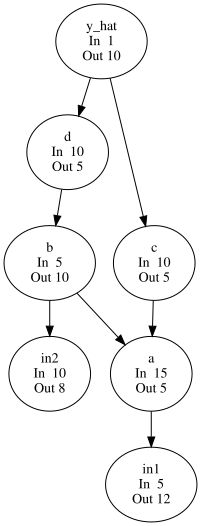

In [ ]:
# reverse the edges in the edge dict (and deduplicate one to many relationships)
kegg_connections_reversed = reverse_edge_dict(edge_dict = kegg_connections)

# use existing graph to define properties of new one (switch inputs/outputs)
prop_dict_reversed = reverse_node_props(
    prop_dict = myvnn.node_props, 
    conversion_dict = {'out':'inp',
                       'inp':'out',
                   'flatten':''})

# use the VNNHelper class to setup the connections but then pass in all the nodes' properties directly
myvnn_rev = VNNHelper(edge_dict = kegg_connections_reversed)
myvnn_rev.node_props = prop_dict_reversed


myvnn_rev.calc_edge_inp()
myvnn_rev.mk_digraph(include = ['node_name', 'inp_size', 'out_size'])

### Calculating Distances between Nodes

In [ ]:
#| export
# consider only one pair of nodes
def vertex_subsequent(
    edge_dict,
    start,
    end
):
    "Count the number of vertices between two nodes (unidirectional)"
    nos = (start not in edge_dict.keys())
    noe = (end not in edge_dict.keys())
    if nos & noe:
        raise Exception('`start` and `end` nodes are not in `edge_dict`')         
    elif nos:
        raise Exception('`start` node is not in `edge_dict`')
    elif noe:
        raise Exception('`end` nodes is not in `edge_dict`')
    else:
        query_list = edge_dict[end]
        for i in range(len(edge_dict.keys())):
            if start in query_list:
                return i
            else:
                query_list = sum([edge_dict[e] for e in [ee for ee in query_list if ee in edge_dict.keys()]], [])
        return None

In [ ]:
#| export

def vertex_between(
    edge_dict,
    node0,
    node1
):
    "Count the number of vertices between two nodes"
    res = vertex_subsequent(
        edge_dict = edge_dict,
        start = node0,
        end =node1)
    if res == None:
        res = vertex_subsequent(
            edge_dict = edge_dict,
            start = node1,
            end =node0)
    return res 

In [ ]:
#| export

def vertex_from_end(
        edge_dict,
        end 
        ):
    "build a reference for all child nodes of a given root"

    # look at edge_dict's entries for all the nodes in a query list. Add them to dict out with value i and return new values and new i (distance from node)
    def _temp(i, query_list):
        new_queries = []
        for e in query_list:
            if e not in edge_dict.keys():
                pass
            else:
                new_queries += edge_dict[e]
                for ee in edge_dict[e]:
                    if ee not in out.keys():
                        out[ee] = i
                    elif out[ee] > i:
                        out[ee] = i
                    else:
                        # entry exists but is not the shortest path
                        pass 
        return new_queries, i+1

    out = {end:0}
    i = 1 
    ql = [end]
        
    # instead of using a while and checking for the base case of an empty list, I'll assume the worst case all nodes are sequential
    for j in range(len(edge_dict.keys())):
        if ql == []:
            break
        else:
            ql, i = _temp(i = i, query_list = ql)

    return out

### Non-Sparse VNN (Dictionary Based)

In [ ]:
#| export
def Linear_block_reps(in_size, out_size, drop_pr, block_reps):
    block_list = []
    for i in range(block_reps):
        if i == 0:
            block_list += [
                nn.Linear(in_size, out_size),
                nn.ReLU(),
                nn.Dropout(drop_pr)]
        else:
            block_list += [
                nn.Linear(out_size, out_size),
                nn.ReLU(),
                nn.Dropout(drop_pr)]

    block = nn.ModuleList(block_list)
    return(block)     

In [ ]:
#| export
class VisableNeuralNetwork(nn.Module):
    def __init__(self, 
                 node_props, 
                 Linear_block,
                 dependancy_order,
                 edge_dict,
                 node_to_inp_num_dict,
                 **kwargs
                ):
        super(VisableNeuralNetwork, self).__init__()
        self.dependancy_order = dependancy_order
        self.edge_dict = edge_dict
        self.node_to_inp_num_dict = node_to_inp_num_dict

        # Figure out what nodes should be outputs. This will be of use for multiple predictions (yield and disease resistance say)
        # and for VAEs.
        all_keys = []
        all_vals = []
        for e in self.edge_dict.keys():
            all_keys += [e]
            all_vals += self.edge_dict[e]
        all_keys = list(set(all_keys))
        all_vals = list(set(all_vals))
        output_names = [e for e in all_keys if e not in all_vals]
        self.output_names = output_names
        
        self.return_dict = False
        if 'return_dict' in kwargs.keys():
            self.return_dict = kwargs['return_dict']

        # Store nodes in dict
        layer_dict = {}
        for key in node_props.keys():
            node_list = []
            if 'flatten' in node_props[key]:
                node_list += [nn.Flatten()]
            node_list += [nn.Flatten()]
            #TODO change linear block instead of conditioning on node name.
            if key not in self.output_names:
                node_list += [Linear_block(
                    in_size=node_props[key]['inp'], 
                    out_size=node_props[key]['out'], 
                    drop_pr=node_props[key]['drop'],
                    block_reps=node_props[key]['reps'])]
            else:
                node_list += [nn.Linear(node_props[key]['inp'], node_props[key]['out'])]

            layer_dict[key] = nn.ModuleList(node_list)

        self.layer_dict = nn.ModuleDict(layer_dict)
        

    def forward(self, x):
        temp_res_dict = {}
        for key in self.dependancy_order:
            
            # if the node depends on raw inputs, get them.
            if key in self.node_to_inp_num_dict:
                xin = [ x[self.node_to_inp_num_dict[key]] ]

            # if the node depends on inputs that have been stored in the lookup dict
            if self.edge_dict[key] != []:
                if xin == None:
                    xin = []
                xin += [temp_res_dict[e] for e in self.edge_dict[key]]
                
            # join all input tensors.
            xin = torch.concat(xin, axis = 1)

            for l in self.layer_dict[key]:
                if type(l) == torch.nn.modules.container.ModuleList:
                    for ll in l:            
                        xin = ll(xin)
                else:
                    xin = l(xin)
                    
            temp_res_dict[key] = xin
            xin = None 
        if (len(self.output_names) == 1) & (self.return_dict == False):
            return temp_res_dict[self.dependancy_order[-1]]
        else:
            return {e:temp_res_dict[e] for e in self.output_names}


In [ ]:
model_vnn = VisableNeuralNetwork(
    node_props = myvnn.node_props,
    Linear_block = Linear_block_reps,
    edge_dict = myvnn.edge_dict,
    dependancy_order = myvnn.dependancy_order,
    node_to_inp_num_dict = {'in1': 0, 'in2': 1},
)

model_vnn(x_list_temp).shape

torch.Size([200, 1])

In [ ]:
# now the reversed version
model_vnn_reverse = VisableNeuralNetwork(
    node_props = myvnn_rev.node_props,
    Linear_block = Linear_block_reps,
    edge_dict = myvnn_rev.edge_dict,
    dependancy_order = myvnn_rev.dependancy_order,
    node_to_inp_num_dict = {'y_hat': 0},
    return_dict = True # With multiple outputs a dictionary will automatically be returned.
)

with torch.no_grad():
    res = model_vnn_reverse([torch.zeros((200, 1))])
    print([(e, res[e].shape) for e in list(res.keys())])

[('in2', torch.Size([200, 8])), ('in1', torch.Size([200, 12]))]


#### Use with multiple models (autoencoding)

In [ ]:
# class plVAE(pl.LightningModule):
#     def __init__(self, vae, kl_coeff = 0.1):
#         super().__init__()
#         self.vae = vae
#         self.kl_coeff = kl_coeff

#     def forward(self, x, return_pqz = False):
#         output = self.vae(x, return_pqz = return_pqz)
#         return output
    
#     def training_step(self, batch, batch_idx):
#         x = batch[0]
#         xhat, p, q, z = self.forward(x, return_pqz = True)
#         # calculate losses
#         ## reconstruction
#         recon_loss = F.mse_loss(xhat, x, reduction='mean')
#         ## KLD
#         log_qz = q.log_prob(z)
#         log_pz = p.log_prob(z)
#         kl = log_qz - log_pz
#         kl = kl.mean()
#         kl *= self.kl_coeff
#         loss = kl + recon_loss
#         self.log('train_loss', loss)
#         return loss#, logs
     
#     def configure_optimizers(self, **kwargs):
#         optimizer = torch.optim.Adam(self.parameters(), **kwargs)
#         return optimizer  

In [ ]:
# [e.shape for e in x_list_temp]

In [ ]:
# node_to_inp_num_dict = {'in1': 0, 'in2':1}
# x_enc = model_vnn(x_list_temp)
# x_enc[0:10]

In [ ]:
# # reparam
# in_channels = 1
# latent_channels = 2

# fc_mu = nn.Sequential(nn.Linear(in_channels, latent_channels))
# fc_log_var = nn.Sequential(nn.Linear(in_channels, latent_channels))

# fc_reverse = nn.Sequential(nn.Linear(latent_channels, in_channels))

# x = x_enc
# # def forward(self, res):
# # x = res         
# mu = fc_mu(x)
# log_var = fc_log_var(x)
# # return([mu, log_var])

# [e[0:3, :] for e in [mu, log_var]]

In [ ]:
# # sample
# std = torch.exp(log_var/2)
# p = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(std))
# q = torch.distributions.Normal(mu, std)
# z = q.rsample()
# # return p, q, z


# # reverse parameterize
# x = z
# xprime = fc_reverse(x)
# xprime[0:3]

In [ ]:
# # x_hat_dict = model_vnn_reverse([x_enc])
# x_hat_dict = model_vnn_reverse([xprime])
# # convert each tensor (flattened output) to the right shape
# for key in x_hat_dict.keys():
#     d_b, d_l = tuple(x_hat_dict[key].shape)
#     x_hat_dict[key] = x_hat_dict[key].reshape((d_b, 4, d_l//4))

In [ ]:
# # loss
# recon_loss = torch.concat([x_hat_dict[e] - x_list_temp[node_to_inp_num_dict[e]] 
#               for e in  node_to_inp_num_dict.keys()], 
#              axis = 2).pow(2).mean()
# # same as 
# # recon_loss = F.mse_loss(
# #     torch.concat([x_hat_dict[e] 
# #                   for e in  node_to_inp_num_dict.keys()], axis = 2),
# #     torch.concat([x_list_temp[node_to_inp_num_dict[e]] 
# #                   for e in  node_to_inp_num_dict.keys()], axis = 2), 
# #                   reduction='mean'
# #                   )
# recon_loss

In [ ]:
# kl_coeff = 0.1

# ## KLD
# log_qz = q.log_prob(z)
# log_pz = p.log_prob(z)
# kl = log_qz - log_pz
# kl = kl.mean()
# kl *= kl_coeff
# loss = kl + recon_loss


In [ ]:
# class DemoDataset(Dataset):
#     def __init__(self, y): self.y = y
#     def __len__(self): return len(self.y[0])
#     def __getitem__(self, idx): return [yy[idx] for yy in self.y]


# training_dataloader = DataLoader(
#     DemoDataset(y = x_list_temp),
#     batch_size = 50, 
#     shuffle = True)

# [e.shape for e in next(iter(training_dataloader))]

In [ ]:
# x_hat_dict['in1'].reshape((200, 4, -1 )).shape

In [ ]:
# y = torch.tensor([[[0, 0, 0], [0, 0, 0], [1, 1, 1]],
#               [[2, 2, 2], [2, 2, 2], [3, 3, 3]]])
# y.shape

In [ ]:
# nn.Flatten()(y).reshape((2, 3, -1))

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()